# 1. Text modality: anxiety severity from the DASS-21 questionnaire

The [DASS-21](https://www.psytoolkit.org/survey-library/depression-anxiety-stress-dass.html) (Depression, Anxiety and Stress Scale) has 21 statements answered on a 0-3 scale. Seven of them form the **anxiety subscale**. This notebook:

1. Extracts the anxiety items and computes the official severity label.
2. Trains and tunes six classifiers to predict the severity from the individual answers.
3. Saves the best model and its predictions on a held-out test set of 116 respondents, which are used by the fusion model in notebook 3.

In [1]:
import os
import pickle
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# SVC(probability=True) raises a FutureWarning on scikit-learn >= 1.9; silence it here and in joblib workers
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["PYTHONWARNINGS"] = "ignore::FutureWarning"

DATA = Path("../data")
MODELS = Path("../models")
OUTPUTS = Path("../outputs")
MODELS.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

## Load the questionnaire responses

In [2]:
dass = pd.read_csv(DATA / "dass21_responses.csv")
dass.columns = dass.columns.str.strip()
print(dass.shape)
print("Missing values:", dass.isnull().sum().sum())
dass.head()

(580, 21)
Missing values: 0


,Hard_to_wind_down,Dryness_of_mouth,could_nt_experience_any_positive _feeling,Breathing_difficulty,Difficult_to_work_up_the_initiative_to_do_things,Overreact_to_situations,Experienced_trembling,nervous_energy,Worried_about_panic_and_make_a_fool_of_myself,Nothing_to_look_forward_to,...,Difficult_to_relax,Down_hearted_and_blue,Intolerant_to_getting_what_I_was_doing,Close_to_panic,Unable_to_become_enthusiastic_about_anything,Wasnt_worth_much_as_a_person,I_felt_that_I_was_rather_touchy,Aware_of_the_action_of_heart_in_the_absence_of_physical_exertion,Scared_without_any_good_reason,Life_was_meaningless
0,3,2,2,2,1,2,2,3,2,1,...,3,3,1,3,0,2,1,3,3,1
1,0,0,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,1,1,0,0
2,3,0,2,1,0,0,0,0,2,2,...,1,2,1,3,0,0,1,0,0,1
3,3,1,0,1,0,0,1,3,1,1,...,1,2,1,3,1,2,1,3,0,1
4,3,2,1,0,1,1,1,1,0,0,...,1,0,1,1,0,0,1,0,1,0


## Anxiety subscale and severity label

The anxiety subscale is made of items 2, 4, 7, 9, 15, 19 and 20. Their sum is doubled to match the full DASS-42 scale and mapped to the standard severity bands:

| Score | Severity |
| --- | --- |
| 0-7 | Normal |
| 8-9 | Mild |
| 10-14 | Moderate |
| 15-19 | Severe |
| 20+ | Extremely severe |

Identical answer patterns are removed first, so the same response cannot appear in both the training and the test set.

In [3]:
ANXIETY_ITEMS = [
    "Dryness_of_mouth",
    "Breathing_difficulty",
    "Experienced_trembling",
    "Worried_about_panic_and_make_a_fool_of_myself",
    "Close_to_panic",
    "Aware_of_the_action_of_heart_in_the_absence_of_physical_exertion",
    "Scared_without_any_good_reason",
]
SEVERITY = ["Normal", "Mild", "Moderate", "Severe", "Extremely severe"]


def severity(score):
    if score <= 7:
        return 0
    if score <= 9:
        return 1
    if score <= 14:
        return 2
    if score <= 19:
        return 3
    return 4


anxiety = dass[ANXIETY_ITEMS].drop_duplicates().reset_index(drop=True)
anxiety_score = anxiety.sum(axis=1) * 2
labels = anxiety_score.apply(severity)

print(f"{len(dass)} responses, {len(anxiety)} unique answer patterns")
labels.map(dict(enumerate(SEVERITY))).value_counts().reindex(SEVERITY)

580 responses, 406 unique answer patterns


Normal               43
Mild                 32
Moderate            117
Severe               61
Extremely severe    153
Name: count, dtype: int64

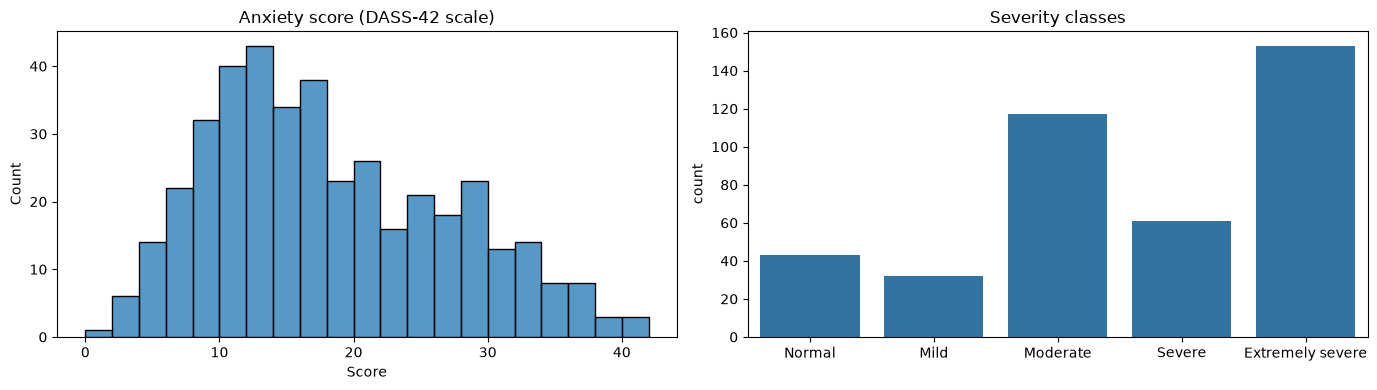

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(anxiety_score, bins=range(0, 44, 2), ax=axes[0])
axes[0].set(title="Anxiety score (DASS-42 scale)", xlabel="Score")
sns.countplot(x=labels.map(dict(enumerate(SEVERITY))), order=SEVERITY, ax=axes[1])
axes[1].set(title="Severity classes", xlabel="")
plt.tight_layout()
plt.show()

## Train/test split

The test set has exactly 116 respondents so it can be paired one-to-one with the 116 test images of the face model in the fusion step. The split is stratified to keep the rare *Mild* class in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    anxiety, labels, test_size=116, random_state=5, stratify=labels
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (290, 7)  Test: (116, 7)


## Baseline models

The classes are imbalanced, so the minority classes are randomly oversampled. The oversampler is part of an `imblearn` pipeline, which means it only ever touches the training data (and, during cross-validation, only the training folds).

In [6]:
def make_pipeline(model):
    return Pipeline([("oversample", RandomOverSampler(random_state=2)), ("model", model)])


models = {
    "XGBoost": XGBClassifier(eval_metric="mlogloss", random_state=0),
    "KNN": KNeighborsClassifier(),
    "Gaussian NB": GaussianNB(),
    "SVM": SVC(probability=True, random_state=0),
    "Decision Tree": DecisionTreeClassifier(random_state=0),
    "Random Forest": RandomForestClassifier(random_state=0),
}


def evaluate(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }


baseline = []
for name, model in models.items():
    pipe = make_pipeline(model).fit(X_train, y_train)
    baseline.append(evaluate(name, y_test, pipe.predict(X_test)))

pd.DataFrame(baseline).set_index("Model").sort_values("Accuracy", ascending=False).round(3)

,Accuracy,Precision,Recall,F1
Model,,,,
SVM,0.845,0.875,0.845,0.853
XGBoost,0.707,0.724,0.707,0.712
Random Forest,0.647,0.670,0.647,0.657
Gaussian NB,0.621,0.758,0.621,0.647
KNN,0.603,0.677,0.603,0.622
Decision Tree,0.603,0.632,0.603,0.616


## Hyperparameter tuning

In [7]:
param_grids = {
    "KNN": {"model__n_neighbors": [5, 7, 8, 10], "model__metric": ["euclidean", "manhattan", "chebyshev", "minkowski"]},
    "Decision Tree": {"model__criterion": ["gini", "entropy"]},
    "Random Forest": {"model__n_estimators": [100, 150, 200], "model__criterion": ["gini", "entropy"]},
    "XGBoost": {"model__n_estimators": [100, 150, 200], "model__learning_rate": [0.1, 0.01, 0.001], "model__max_depth": [3, 5, 7]},
    "SVM": {"model__C": [0.1, 1, 10], "model__kernel": ["linear", "rbf", "poly"], "model__gamma": ["scale", "auto"]},
    "Gaussian NB": {},
}

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=0)
searches = {}
for name, grid in param_grids.items():
    search = GridSearchCV(make_pipeline(models[name]), grid, scoring="accuracy", cv=cv, n_jobs=-1)
    searches[name] = search.fit(X_train, y_train)

tuned = pd.DataFrame(
    [
        {**evaluate(name, y_test, s.predict(X_test)), "CV accuracy": s.best_score_, "Best params": s.best_params_}
        for name, s in searches.items()
    ]
).set_index("Model").sort_values("CV accuracy", ascending=False)
tuned.round(3)

,Accuracy,Precision,Recall,F1,CV accuracy,Best params
Model,,,,,,
SVM,1.000,1.000,1.000,1.000,1.000,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
XGBoost,0.724,0.749,0.724,0.730,0.721,"{'model__learning_rate': 0.1, 'model__max_dept..."
Random Forest,0.672,0.679,0.672,0.675,0.690,"{'model__criterion': 'entropy', 'model__n_esti..."
Gaussian NB,0.621,0.758,0.621,0.647,0.679,{}
KNN,0.603,0.714,0.603,0.631,0.645,"{'model__metric': 'euclidean', 'model__n_neigh..."
Decision Tree,0.603,0.632,0.603,0.616,0.641,{'model__criterion': 'gini'}


The model with the best cross-validated accuracy is selected (the test set plays no part in the choice).

Best model: SVM {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
                  precision    recall  f1-score   support

          Normal       1.00      1.00      1.00        12
            Mild       1.00      1.00      1.00         9
        Moderate       1.00      1.00      1.00        34
          Severe       1.00      1.00      1.00        17
Extremely severe       1.00      1.00      1.00        44

        accuracy                           1.00       116
       macro avg       1.00      1.00      1.00       116
    weighted avg       1.00      1.00      1.00       116



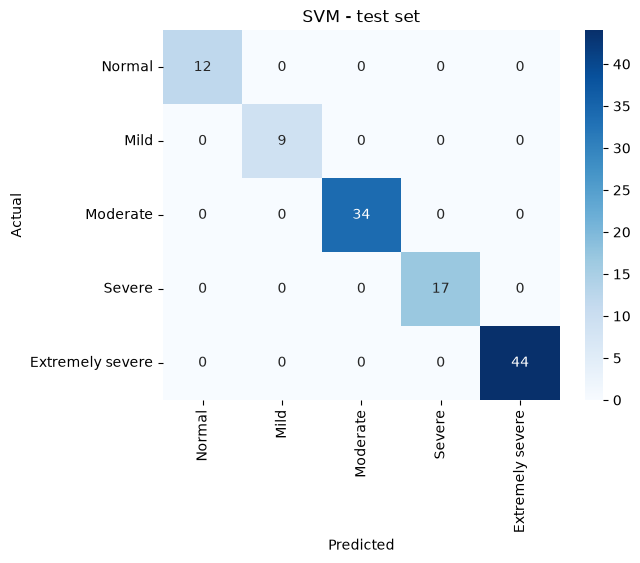

In [8]:
best_name = tuned.index[0]
best_model = searches[best_name].best_estimator_
y_pred = best_model.predict(X_test)

print(f"Best model: {best_name} {searches[best_name].best_params_}")
print(classification_report(y_test, y_pred, target_names=SEVERITY, zero_division=0))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", xticklabels=SEVERITY, yticklabels=SEVERITY, cmap="Blues")
plt.title(f"{best_name} - test set")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save the model and test predictions

For fusion the severity is reduced to a binary label: **anxiety** (mild or worse) vs **no anxiety** (normal). The probability of anxiety is `1 - P(Normal)`.

In [9]:
with open(MODELS / "text_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

text_predictions = pd.DataFrame(
    {
        "severity_true": y_test.to_numpy(),
        "severity_pred": y_pred,
        "anxiety_true": (y_test.to_numpy() > 0).astype(int),
        "anxiety_pred": (y_pred > 0).astype(int),
        "p_anxiety": 1 - best_model.predict_proba(X_test)[:, 0],
    }
)
text_predictions.to_csv(OUTPUTS / "text_predictions.csv", index=False)

print(f"Binary anxiety accuracy: {accuracy_score(text_predictions.anxiety_true, text_predictions.anxiety_pred):.3f}")
text_predictions.head()

Binary anxiety accuracy: 1.000


,severity_true,severity_pred,anxiety_true,anxiety_pred,p_anxiety
0,2,2,1,1,0.999028
1,3,3,1,1,0.995913
2,4,4,1,1,0.999122
3,3,3,1,1,0.995619
4,4,4,1,1,1.000000


## Predict a new respondent

In [10]:
answers = pd.DataFrame(
    [
        {
            "Dryness_of_mouth": 1,
            "Breathing_difficulty": 2,
            "Experienced_trembling": 2,
            "Worried_about_panic_and_make_a_fool_of_myself": 1,
            "Close_to_panic": 2,
            "Aware_of_the_action_of_heart_in_the_absence_of_physical_exertion": 0,
            "Scared_without_any_good_reason": 3,
        }
    ]
)
with open(MODELS / "text_model.pkl", "rb") as f:
    text_model = pickle.load(f)

print("Score:", answers.sum(axis=1).iloc[0] * 2, "->", SEVERITY[severity(answers.sum(axis=1).iloc[0] * 2)])
print("Predicted:", SEVERITY[text_model.predict(answers)[0]])

Score: 22 -> Extremely severe
Predicted: Extremely severe
